In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import sys
import re
import json
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
import ddddocr
import torch
from torchvision.models import resnet18, ResNet18_Weights
from copy import copy
import pyautogui
from datetime import datetime
import time
from tqdm import tqdm
from torch import nn
import torch.nn.functional as F
import math
from scipy.ndimage import median_filter

In [49]:
# 全局配置
class NanokaDetector():
    def __init__(self, image=None):
        super(NanokaDetector, self).__init__()

        if image != None:
            self.image = image
            self.gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        else:
            self.image = None
            self.gray = None
        
        self.ocr = ddddocr.DdddOcr(show_ad=False)

    def update_image(self, image):
        '''
        更新使用的图片, 我们可以直接调取这个图片进行分析
        '''
        self.image = image
        self.gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
                         
    # 亮点综合检测器
    def threhold_detector(self, plot=False, show=False):
        '''
        利用检测点的圆形高亮特性确定目标点
        '''
        # 一顿操作最后只剩下需要的信息
        _, binary_image = cv2.threshold(self.gray, 155, 255, cv2.THRESH_BINARY)
        blured_image = cv2.blur(binary_image, (9,9))
        median_image = cv2.medianBlur(blured_image, 7)
        _, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
        
        # 掩膜
        height, width = self.gray.shape
        border_ratio = 0.1
        mask = np.zeros_like(self.gray, dtype=np.uint8)
        border_x = int(width * border_ratio)
        border_y = int(height * border_ratio)
        inner_width = width - 2 * border_x
        inner_height = height - 2 * border_y
        cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
        masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)
        
        # 提取大范围亮色特征 (轮廓分析)
        targets, anti_targets = [], []
        origin_image = None
        if plot:
            origin_image = self.image.copy()
            # 绘制掩膜
            cv2.rectangle(origin_image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)
    
        # 抓住所有需要的点特征
        contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            center_x, center_y = x + w // 2, y + h // 2
            targets.append((center_x, center_y, w, h))
            
            if plot:
                cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
                cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

        # 消除不需要的点特征
        masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)
        acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in acontours:
            x, y, w, h = cv2.boundingRect(contour)
            center_x, center_y = x + w // 2, y + h // 2
            anti_targets.append((center_x, center_y, w, h))
            
            if plot:
                cv2.rectangle(origin_image, (x-5, y-5), (x+w+5, y+h+5), (255, 0, 0), 2)  # 红色矩形
    
        if show:
            fig, axes = plt.subplots(1, 1, figsize=(10, 6))
            axes.imshow(origin_image)
            axes.set_title("Analyzed Image")
            plt.show()
        
        return np.array(targets, dtype=np.float32), np.array(anti_targets, dtype=np.float32), origin_image

    def ocr_detector(self, border_ratio=0.1):
        '''
        ddddocr 图像文字识别
        '''
        height, width = self.gray.shape
        mask = np.zeros_like(self.gray, dtype=np.uint8)
        border_x = int(width * border_ratio)
        border_y = int(height * border_ratio)
        
        text_area = self.gray[height-border_y:, :border_x]    
        _, encoded_img = cv2.imencode('.png', text_area)
        img_bytes = encoded_img.tobytes()
    
        # 只能检测编码字节流
        result = self.ocr.classification(img_bytes)
        return result

    def re_keyword_detector(self, texts):
        """
        ASCII字符清洗检测子串, 子串是提前规定好的
        """
        patterns = [r'添[\x00-\x7F]{0,3}加[\x00-\x7F]{0,3}好[\x00-\x7F]{0,3}友', r'好[\x00-\x7F]{0,3}友', r'挚[\x00-\x7F]{0,3}友']
        dataframes = {
            '识别文本': [],
            '星盘页': [],
            '添加好友': [],
            '好友': [],
            '挚友': [],
        }
    
        for text in texts:
            matchs = list([bool(re.search(pattern, text)) for pattern in patterns])
            dataframes['星盘页'].append(True in matchs)
            dataframes['添加好友'].append(matchs[0] == True)
            dataframes['好友'].append(matchs[1] == True)
            dataframes['挚友'].append(matchs[2] == True)
            dataframes['识别文本'].append(text)
            
        return pd.DataFrame(dataframes)

    # 圆形检测器
    def hough_detector(self, plot=False, show=False):
        '''
        使用霍夫变换检测圆形目标, 为后续提供支持
        '''
        min_radius=1
        max_radius=35
    
        # 使用霍夫圆变换检测圆形
        circles = cv2.HoughCircles(
            masked_edges,               # 输入图像（边缘图）
            cv2.HOUGH_GRADIENT,         # 检测方法（梯度法）
            dp=1,                       # 累加器图像的分辨率与原图之比
            minDist=50,                 # 检测到的圆的圆心之间的最小距离
            param1=50,                  # Canny边缘检测器的高阈值
            param2=25,                  # 累加器阈值（越小检测到的圆越多）
            minRadius=min_radius,       # 最小圆半径
            maxRadius=max_radius        # 最大圆半径
        )
    
        # 复制原图用于绘制结果
        origin_image = None
        if plot:
            origin_image = self.image.copy()
            cv2.rectangle(origin_image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)

        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            if plot:
                for (x, y, r) in circles:
                    cv2.circle(origin_image, (x, y), r, (0, 255, 0), 4)
        else:
            print("No detection.")
            
        if show:
            fig, axes = plt.subplots(1, 1, figsize=(10, 6))
            axes.imshow(origin_image, cmap="gray")
            axes.set_title("Masked Hough transform Image")
            plt.show()
            
        return circles, origin_image


    def image_spiltor(self):
        '''
        用于将数据切分成我们想要的形式之后进行分类任务就可以了
        '''
        targets, anti_targets, plot_image = self.threhold_detector(plot=False, show=False)

        diff = np.expand_dims(targets[:,:2], axis=1) - np.expand_dims(anti_targets[:,:2], axis=0)
        distance = np.sqrt(np.sum(diff*diff, axis=2))
        point = np.where(distance < 15)[0]
        post = copy(targets[point])
        pre = [i for i in targets.tolist() if i not in post]

        # 不同的类别进行不同的切割方式, pre 是需要进一步处理的内容, post是确定的很大的不需要处理的内容
        pre_scaler, post_scaler = 5, 2
        pre_sub_gray = [self.gray[int(y-max(w,h)*pre_scaler):int(y+max(w, h)*pre_scaler), int(x-max(w, h)*pre_scaler):int(x+max(w, h)*pre_scaler)] for x, y, w, h in pre]
        post_sub_gray = [self.gray[int(y-max(w,h)*post_scaler):int(y+max(w, h)*post_scaler), int(x-max(w, h)*post_scaler):int(x+max(w, h)*post_scaler)] for x, y, w, h in post]
        return pre_sub_gray, post_sub_gray, pre, post

    def light_circle(self, image, radius=12):
        '''
        检测圆形掩码内是都不为 0
        '''
        x, y = 112, 112
        height, width = image.shape
        yy, xx = np.ogrid[:height, :width]
        distance_squared = (xx - x) ** 2 + (yy - y) ** 2
        circle_mask = distance_squared <= radius ** 2
        circle_pixels = image[circle_mask]
        return np.all(circle_pixels != 0)

    def analyze_octagram(self, images):
        '''
        检测图形中是否出现八角星星，如果没有出现我们就认为没有，如果过于混乱我们也不考虑, 我们可以校验圆心处的同心圆是否为单色
        '''
        if len(images) == 0:
            # 没有任何有效图像, 草这是为什么?
            print("(analyze_octagram) 没有检测到有效图像")
            return [], []
            
        # 旋转45度计算差值
        rotation_matrix = cv2.getRotationMatrix2D((112,112), 45, 1.0)
        resize_images = [cv2.threshold(cv2.resize(gray, (224, 224)), 50, 255, cv2.THRESH_BINARY)[1] for gray in images]
        route_resize_images = [cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in resize_images]
        diff_images = [np.abs(np.array(r1, dtype=np.float32) - np.array(r2, dtype=np.float32)) for r1, r2 in zip(route_resize_images, resize_images)]
        diff_images = [cv2.threshold(cv2.blur(gray, (5,5)), 150, 255, cv2.THRESH_BINARY)[1] for gray in diff_images]

        # 使图像旋转八次并且堆叠在一起
        feature_map = [diff_images]
        for i in range(7):
            feature_map.append([cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in feature_map[-1]])
        stacked_features = np.array(feature_map)
        image_result = np.ones((len(diff_images), 224, 224), dtype=np.uint8)
        for i in range(8):
            image_result = image_result * (stacked_features[i] > 0)
        image_result = image_result.astype(np.uint8)

        # 计算四条准线
        feature_list = []
        for gray in image_result:
            x = np.arange(224)
            y = np.arange(224)
            xx, yy = np.meshgrid(x, y)
            
            lines = [gray[112, :], gray[:, 112], gray[yy == xx], gray[yy == 223 - xx]]
            feature_list.append(np.array(lines))

        # 计算反向掩膜, 一般掩膜内不应该存在三个及以上圆环
        analyze_list = []
        for i in range(len(feature_list)):
            data = np.average(np.array([(feature_list[i][j] + feature_list[i][j][::-1])/2 for j in range(feature_list[i].shape[0])]), axis=0)
            binary_data = np.where(data != 0, 1, 0)
            first_half = binary_data[:112]
            second_half = binary_data[112:][::-1]
            comparison = np.logical_and(first_half, second_half)
            processed = median_filter(comparison, size=11)
            analyze_list.append([1 if i else 0 for i in processed])

        # 计算边沿
        radius_list, octagram_detect_result = [], []
        for i, data in enumerate(analyze_list):
            # diff = np.diff(data[50:]) # 我们假设圆环不可能出现在外边界, 因为我毕竟抓了好几倍边长呢
            diff = np.diff(data) # 现实总是出乎意料的, 真的分布采样到外面去了 (流汗)
            rising_edges = np.where(diff == 1)[0] + 51
            falling_edges = np.where(diff == -1)[0] + 51
        
            if len(rising_edges) != len(falling_edges):
                fig, axes = plt.subplots(2, 5, figsize=(12, 4))
                for i, ax in enumerate(axes.flatten()):
                    if i < len(analyze_list):
                        ax.plot(analyze_list[i])
                        ax.set_title('Analyze Plot Figure{}'.format(i))
                        plt.ylim(0, 1)
                plt.tight_layout()
                plt.show()
                raise RuntimeError("上升沿与下降沿不匹配")
            if len(rising_edges) >= 3: # 不应该有这么多有效边沿, 除非是大文字
                octagram_detect_result.append(0) # cls 0 就是背景色
                radius_list.append([False, -1, -2])
                continue
            if len(rising_edges) == 0:
                if self.light_circle(cv2.threshold(cv2.resize(images[i], (224, 224)), 50, 255, cv2.THRESH_BINARY)[1]):
                    radius_list.append([False, -1, -1])
                    octagram_detect_result.append(2) # cls 2 就是已经送了心火的, 后续还要进一步检测是否有星屑
                else:
                    radius_list.append([False, -1, -2])
                    octagram_detect_result.append(0) # 中心圆不存在就是背景图
            else:
                index = np.argmax(falling_edges - rising_edges)
                radius = 112 - (falling_edges[index] + rising_edges[index])/2
                if falling_edges[index] - rising_edges[index] > 15: # 经验值
                    if self.light_circle(cv2.threshold(cv2.resize(images[i], (224, 224)), 50, 255, cv2.THRESH_BINARY)[1]):
                        radius_list.append([True, radius, falling_edges[index] - rising_edges[index]])
                        octagram_detect_result.append(2) # cls 1 就是还没有送心火的, 直接点击就可以了根据星盘状态去判断
                    else:
                        radius_list.append([False, -1, -2])
                        octagram_detect_result.append(0) # 中心圆不存在就是背景图
                else:
                    radius_list.append([False, -1, -1])
                    octagram_detect_result.append(0) # 识别错成了小星光, 也属于背景的一种
                    
        return octagram_detect_result, radius_list
        
    def multi_detector(self, border_ratio=0.1, plot=False, show=False):
        '''
        多重鉴别器, 用于检测是否在星盘页并且判断类型
        '''
        text = self.ocr_detector()
        pf = self.re_keyword_detector([text])
    
        if not bool(pf['星盘页'].values[0]):
            print("不在星盘页, 不进行后续检测")
            if show:
                fig, axes = plt.subplots(1, 1, figsize=(15, 5))
                axes.imshow(self.image)
                axes.set_title("Useless Image")
                axes.axis('off')
                plt.show()
            return {"code":-1, "info":"不在星盘页"}, None
    
        if bool(pf['添加好友'].values[0]):
            print("当前页面为添加好友页")
            if show:
                fig, axes = plt.subplots(1, 1, figsize=(15, 5))
                axes.imshow(self.image)
                axes.set_title("Make Friends Image")
                axes.axis('off')
                plt.show()
            return {"code":1, "info":"本页面为添加好友页"}, None
    
        if bool(pf['好友'].values[0]) or bool(pf['挚友'].values[0]):
            print("检测为有效的星盘页")
            
            # 首先计算出我们的小点和大点
            pre_sub_gray, post_sub_gray, pre_points, post_points =  self.image_spiltor()

            pre_octagram_detect_result, pre_radius_list = self.analyze_octagram(pre_sub_gray)
            post_octagram_detect_result, post_radius_list = self.analyze_octagram(post_sub_gray)

######################################################################################################################################################
            # 原图像
            print("图像点为:", pre_points)
            print("\n检测结果:", pre_octagram_detect_result, "\n{}".format(pre_radius_list))
            fig, axes = plt.subplots(2, 5, figsize=(10, 4))
            for i, ax in enumerate(axes.flatten()):
                if i < len(pre_sub_gray):
                    ax.imshow(pre_sub_gray[i], cmap='gray')
                    ax.set_title('pre_sub_gray {}'.format(i))
                ax.axis('off')
            plt.tight_layout()
            plt.show()

            print("图像点为:", post_points)
            print("\n检测结果:", post_octagram_detect_result, "\n{}".format(post_radius_list))
            fig, axes = plt.subplots(1, 5, figsize=(10, 2))
            for i, ax in enumerate(axes.flatten()):
                if i < len(post_sub_gray):
                    ax.imshow(post_sub_gray[i], cmap='gray')
                    ax.set_title('post_sub_gray {}'.format(i))
                ax.axis('off')
            plt.tight_layout()
            plt.show()
######################################################################################################################################################
            if show:
                fig, axes = plt.subplots(1, 1, figsize=(15, 5))

                # 给每一个检测结果绘制圆圈
                img = self.image.copy()
                for i,(cls,r,(cx,cy,w,h)) in enumerate(zip(pre_octagram_detect_result, pre_radius_list, pre_points)):
                    if int(cls) == 1:
                        cv2.circle(img, (cx, cy), r, (255,0,0), 8) # 未送心火绘制成红色
                    if int(cls) == 1:
                        cv2.circle(img, (cx, cy), r, (0,255,0), 8) # 送了心火绘制成绿色
                axes.imshow(img)
                axes.set_title("MultiDetector Figure")
                axes.axis('off')
                plt.tight_layout()
                plt.show()
            return {"code":0, "info":"识别成功"}, img
        return {"code":-2, "info":"无法预知的错误!"}, None



Processing btn_gift.png...
不在星盘页, 不进行后续检测


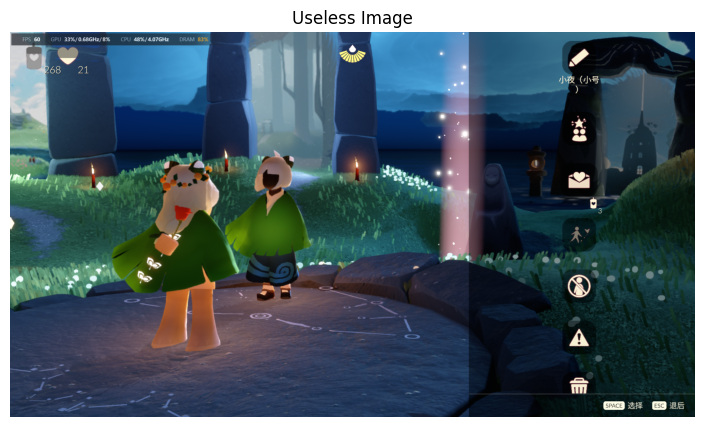



Processing frame.jpg...
检测为有效的星盘页
图像点为: [[945.0, 732.0, 9.0, 9.0], [1245.0, 728.0, 9.0, 8.0], [1377.0, 649.0, 10.0, 10.0], [379.0, 641.0, 11.0, 11.0], [1017.0, 585.0, 9.0, 9.0], [1436.0, 405.0, 10.0, 9.0], [488.0, 398.0, 7.0, 8.0], [1048.0, 324.0, 10.0, 10.0], [1625.0, 265.0, 9.0, 9.0], [564.0, 254.0, 10.0, 10.0], [1168.0, 253.0, 10.0, 10.0]]

检测结果: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 
[[True, np.float64(-15.0), np.int64(32)], [True, np.float64(-15.5), np.int64(29)], [True, np.float64(-19.5), np.int64(27)], [True, np.float64(-21.5), np.int64(25)], [True, np.float64(-15.5), np.int64(31)], [True, np.float64(-21.5), np.int64(25)], [True, np.float64(-14.5), np.int64(31)], [True, np.float64(-21.0), np.int64(24)], [True, np.float64(-19.0), np.int64(26)], [True, np.float64(-22.0), np.int64(22)], [True, np.float64(-21.0), np.int64(24)]]


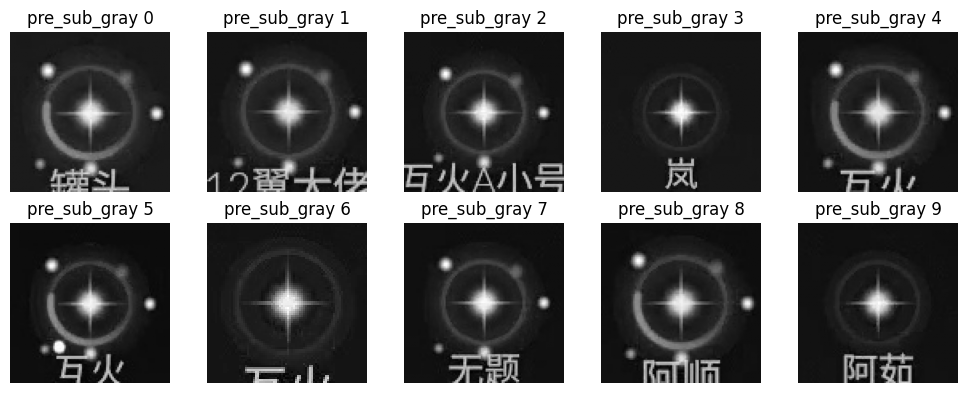

图像点为: [[643. 922.  22.  22.]
 [725. 912.  13.  14.]
 [340. 832.  20.  21.]
 [216. 801.  26.  18.]
 [474. 778.  13.  12.]
 [388. 767.  13.  13.]
 [295. 763.  12.  13.]]

检测结果: [2, 2, 2, 2, 2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [True, np.float64(18.0), np.int64(44)], [True, np.float64(17.5), np.int64(45)], [True, np.float64(18.5), np.int64(47)]]


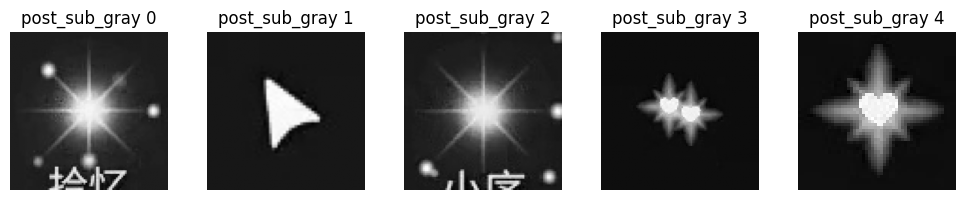

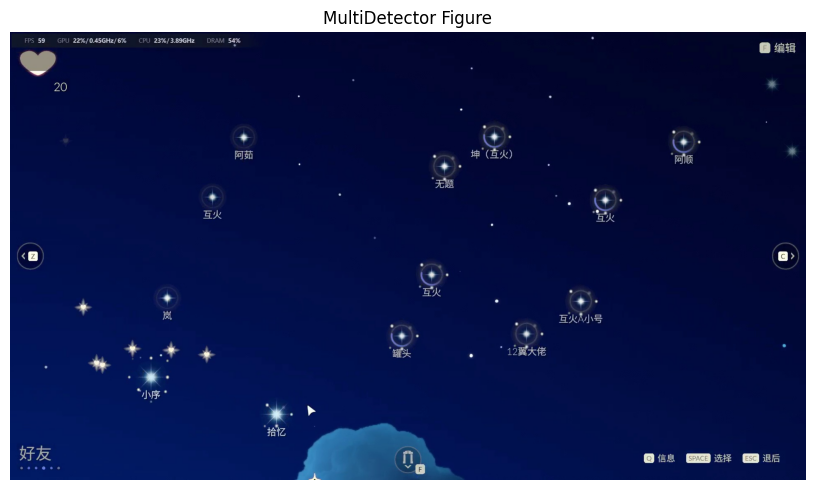



Processing frame2.jpg...
检测为有效的星盘页
图像点为: [[1535.0, 890.0, 9.0, 10.0], [1574.0, 744.0, 6.0, 5.0], [731.0, 718.0, 10.0, 9.0], [805.0, 572.0, 10.0, 9.0], [1238.0, 441.0, 8.0, 10.0], [402.0, 335.0, 6.0, 5.0], [1431.0, 218.0, 11.0, 11.0]]

检测结果: [2, 0, 2, 2, 0, 2, 2] 
[[True, np.float64(-24.0), np.int64(20)], [False, -1, -2], [True, np.float64(-22.5), np.int64(23)], [True, np.float64(-22.5), np.int64(23)], [False, -1, -2], [True, np.float64(1.5), np.int64(37)], [False, -1, -1]]


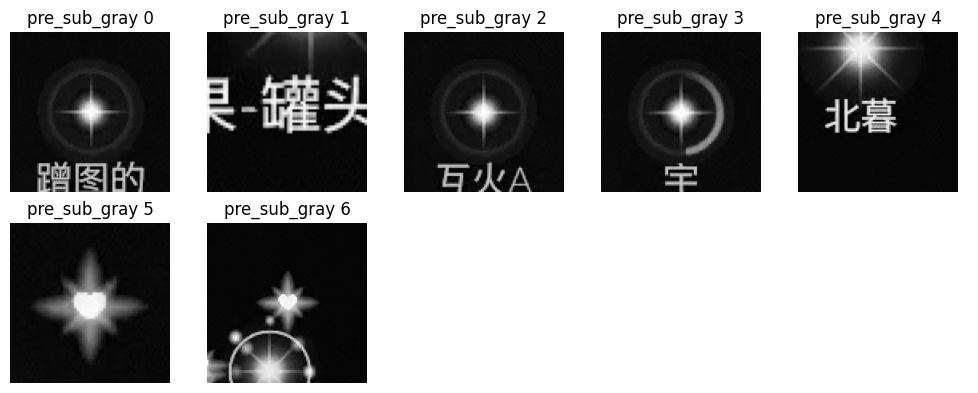

图像点为: [[ 426.  901.   21.   21.]
 [1030.  719.   21.   21.]
 [1583.  699.   18.   17.]
 [1163.  643.   21.   21.]
 [1227.  401.   20.   19.]
 [ 281.  374.   21.   21.]
 [ 841.  312.   19.   18.]
 [1420.  303.   15.   18.]
 [1419.  265.   16.   16.]
 [1371.  276.   19.   43.]
 [ 963.  243.   16.   17.]
 [ 359.  232.   19.   20.]]

检测结果: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1]]


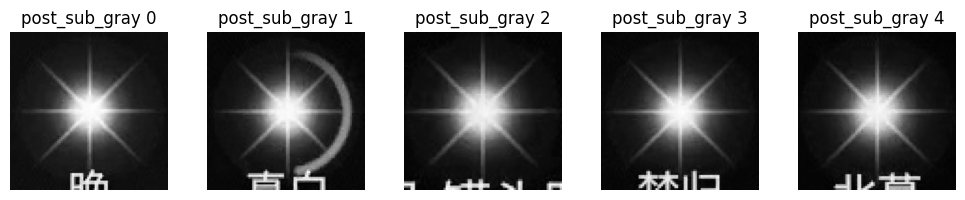

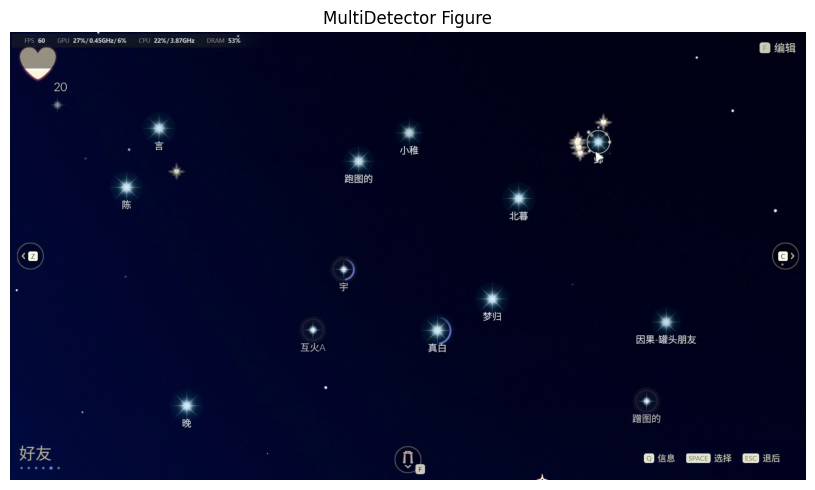



Processing frame3.jpg...
检测为有效的星盘页
图像点为: [[1528.0, 932.0, 6.0, 6.0]]

检测结果: [0] 
[[False, -1, -2]]


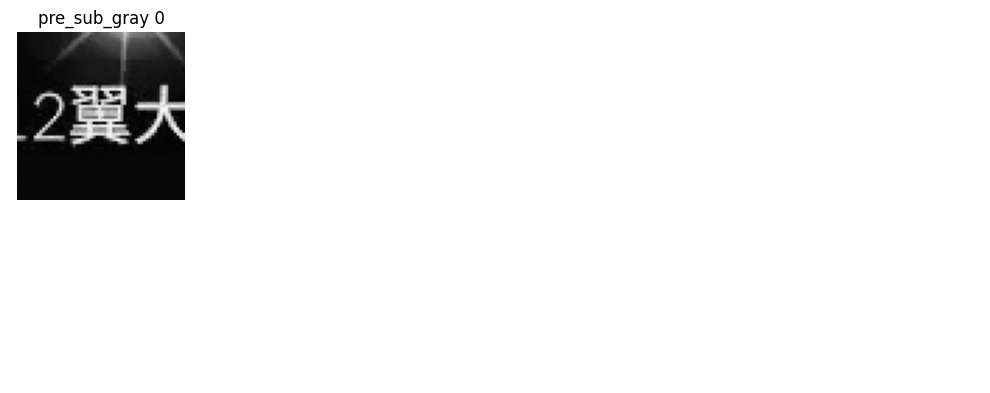

图像点为: [[ 427.  902.   21.   21.]
 [1537.  889.   21.   21.]
 [1032.  720.   20.   20.]
 [ 732.  718.   19.   19.]
 [1584.  699.   16.   17.]
 [1164.  644.   20.   19.]
 [ 806.  572.   21.   21.]
 [1075.  452.   12.   14.]
 [1228.  402.   20.   19.]
 [ 282.  375.   19.   19.]
 [ 842.  312.   19.   18.]
 [1420.  264.   21.   21.]
 [ 963.  243.   17.   17.]
 [ 360.  233.   20.   21.]]

检测结果: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1]]


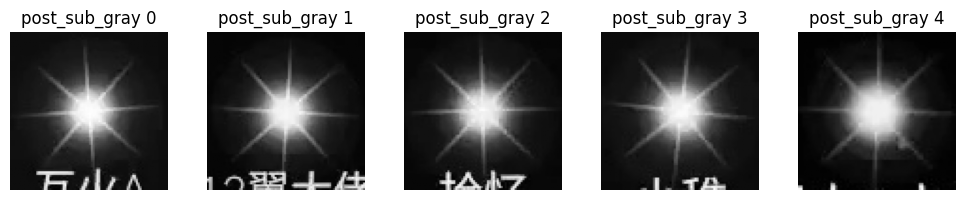

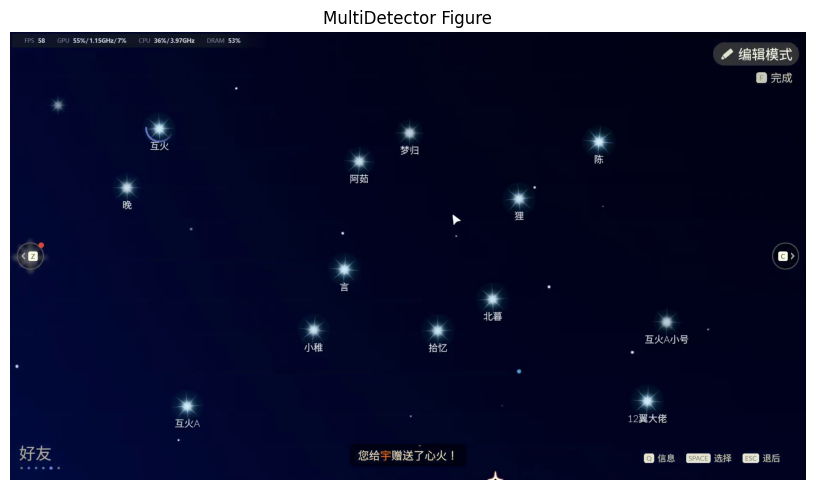



Processing main.png...
检测为有效的星盘页
(analyze_octagram) 没有检测到有效图像
图像点为: []

检测结果: [] 
[]


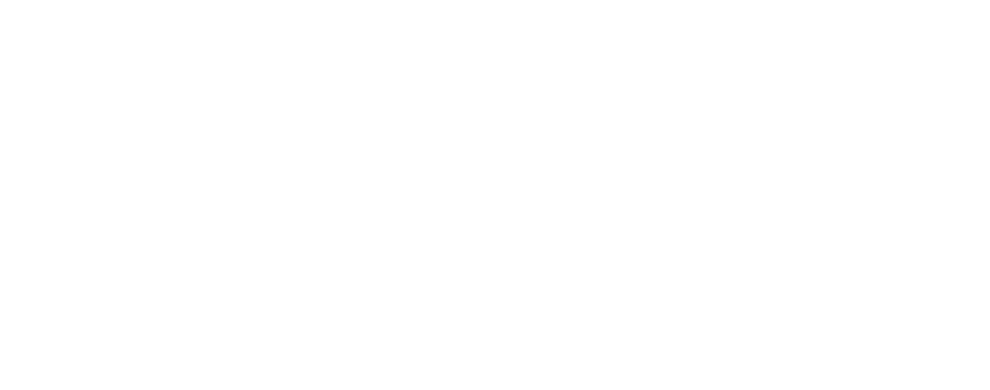

图像点为: [[539. 364.  19.  19.]]

检测结果: [2] 
[[False, -1, -1]]


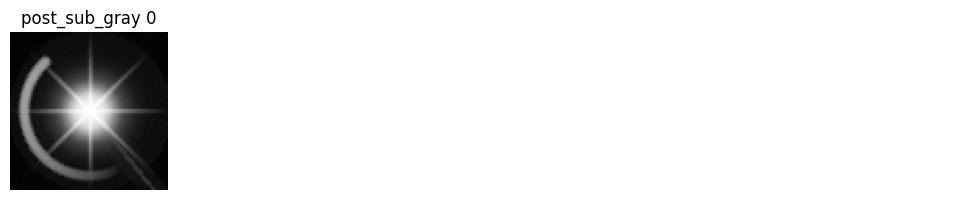

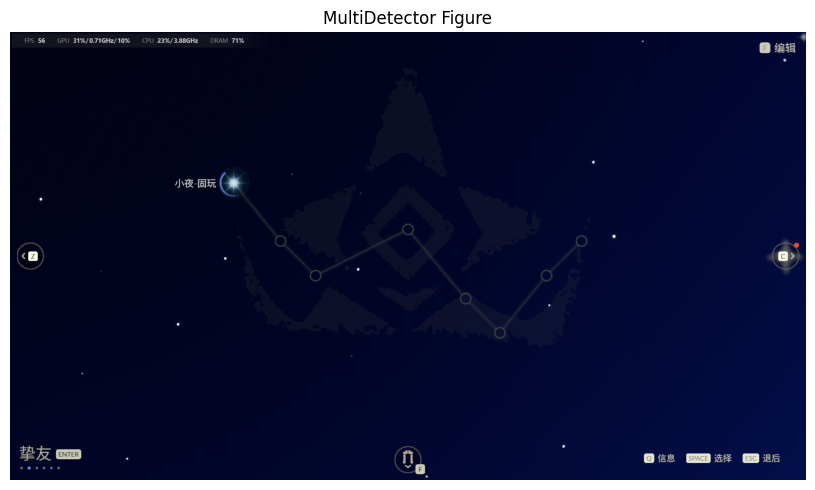



Processing main2.png...
检测为有效的星盘页
图像点为: [[582.0, 319.0, 8.0, 7.0]]

检测结果: [2] 
[[True, np.float64(-16.0), np.int64(30)]]


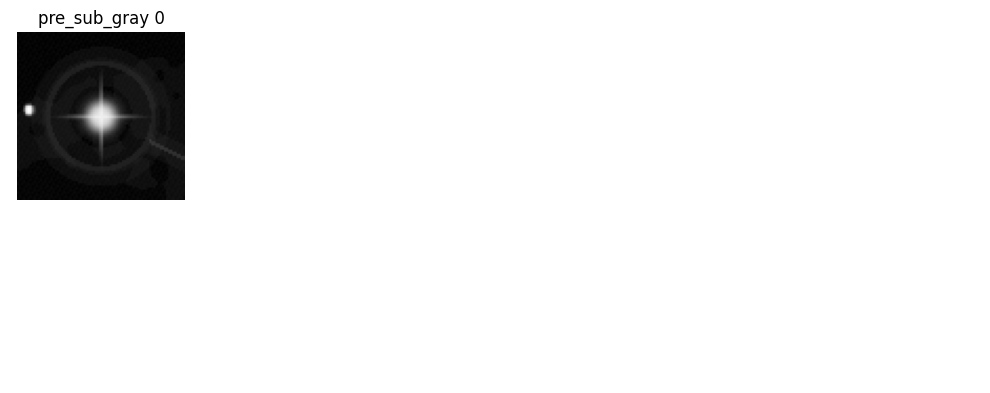

图像点为: [[976. 209.  18.  18.]]

检测结果: [2] 
[[False, -1, -1]]


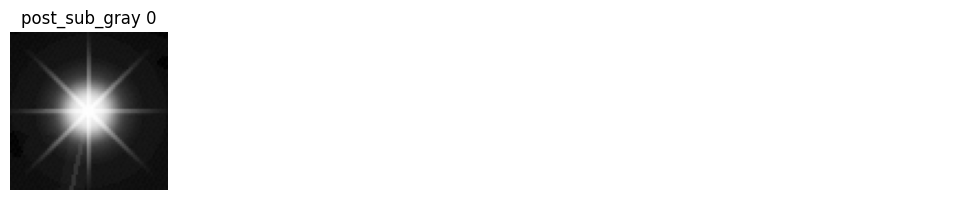

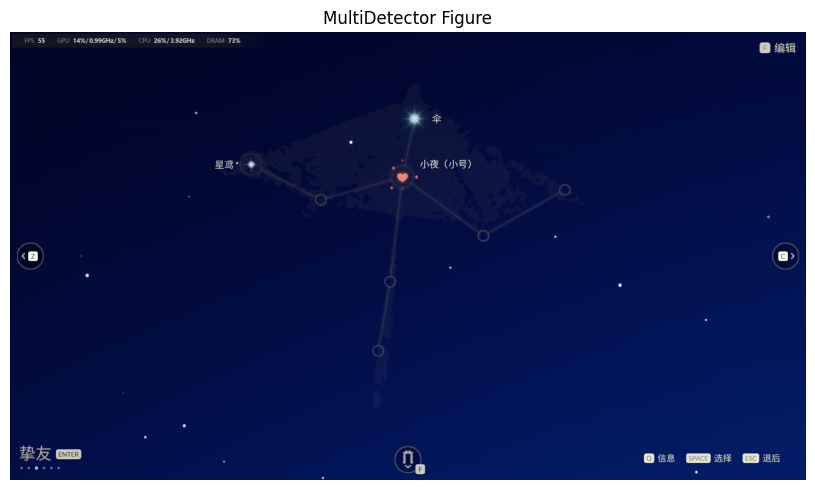



Processing page.png...
当前页面为添加好友页


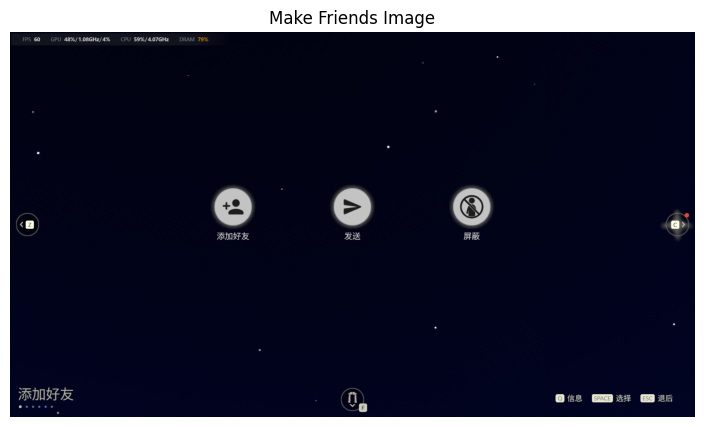



Processing receive.png...
不在星盘页, 不进行后续检测


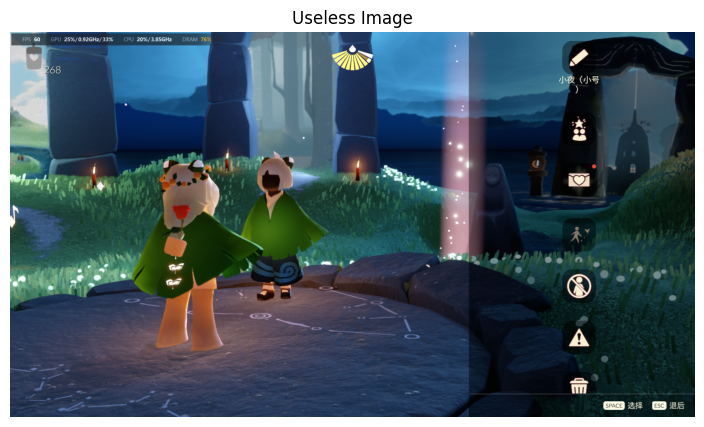



Processing side.png...
检测为有效的星盘页
图像点为: [[642.0, 922.0, 7.0, 8.0], [340.0, 832.0, 8.0, 7.0], [945.0, 733.0, 10.0, 10.0], [1246.0, 728.0, 8.0, 7.0], [1377.0, 650.0, 8.0, 8.0], [379.0, 642.0, 10.0, 10.0], [1017.0, 586.0, 10.0, 10.0], [1048.0, 324.0, 8.0, 7.0], [1625.0, 266.0, 6.0, 6.0], [563.0, 254.0, 7.0, 7.0]]

检测结果: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 
[[True, np.float64(-11.0), np.int64(36)], [True, np.float64(-6.5), np.int64(45)], [True, np.float64(-16.5), np.int64(31)], [True, np.float64(-16.5), np.int64(27)], [True, np.float64(-14.0), np.int64(30)], [True, np.float64(-16.5), np.int64(31)], [True, np.float64(-18.0), np.int64(28)], [True, np.float64(-17.5), np.int64(27)], [True, np.float64(-12.0), np.int64(26)], [True, np.float64(-14.0), np.int64(28)]]


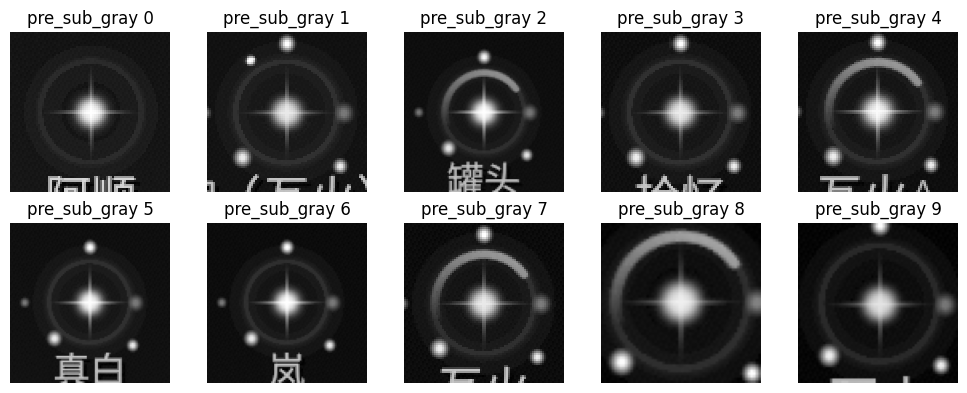

图像点为: [[1436.  406.   18.   18.]
 [ 488.  398.   17.   17.]
 [1168.  253.   21.   21.]]

检测结果: [2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1]]


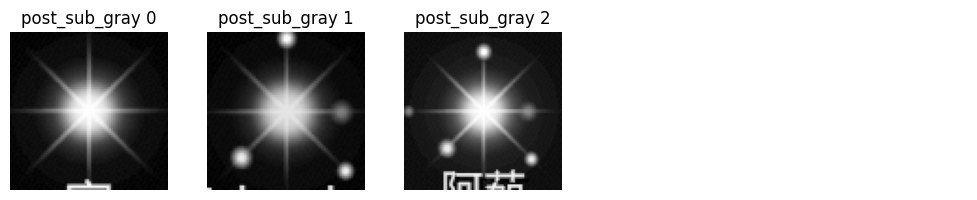

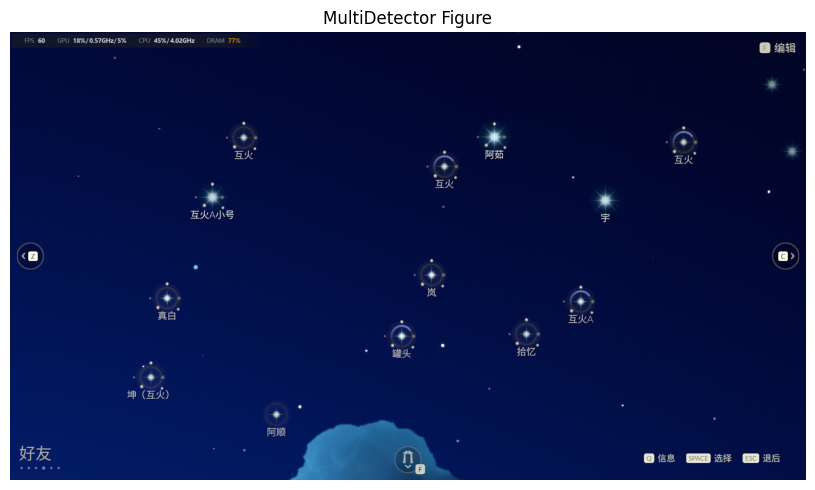



Processing side2.png...
检测为有效的星盘页
图像点为: [[711.0, 758.0, 4.0, 4.0], [1030.0, 719.0, 11.0, 11.0], [1162.0, 643.0, 7.0, 7.0], [805.0, 572.0, 8.0, 9.0], [835.0, 357.0, 4.0, 3.0], [802.0, 351.0, 2.0, 2.0]]

检测结果: [2, 2, 2, 2, 0, 0] 
[[True, np.float64(-13.5), np.int64(21)], [True, np.float64(-24.0), np.int64(22)], [True, np.float64(-18.5), np.int64(19)], [True, np.float64(-21.5), np.int64(23)], [False, -1, -2], [False, -1, -1]]


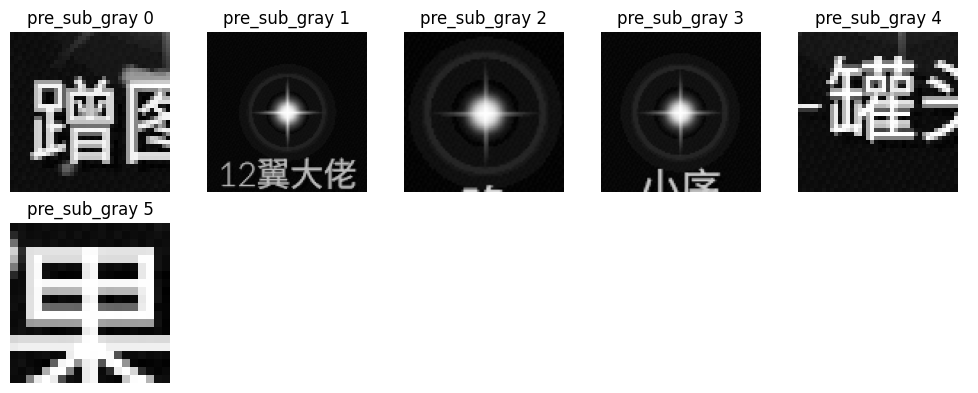

图像点为: [[ 426.  901.   22.   22.]
 [1535.  890.   21.   21.]
 [ 730.  718.   18.   18.]
 [1582.  699.   17.   17.]
 [1227.  402.   18.   18.]
 [ 281.  374.   20.   19.]
 [ 841.  312.   20.   20.]
 [1419.  265.   18.   19.]
 [ 962.  243.   17.   17.]
 [ 359.  232.   19.   20.]]

检测结果: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1]]


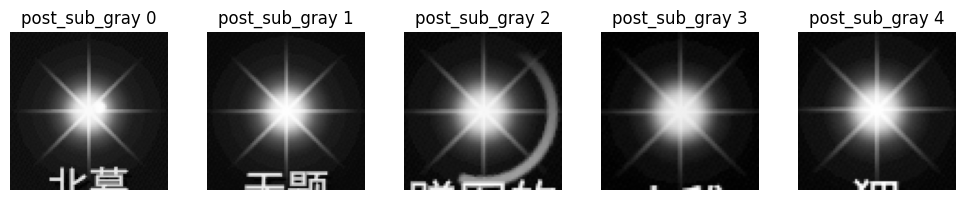

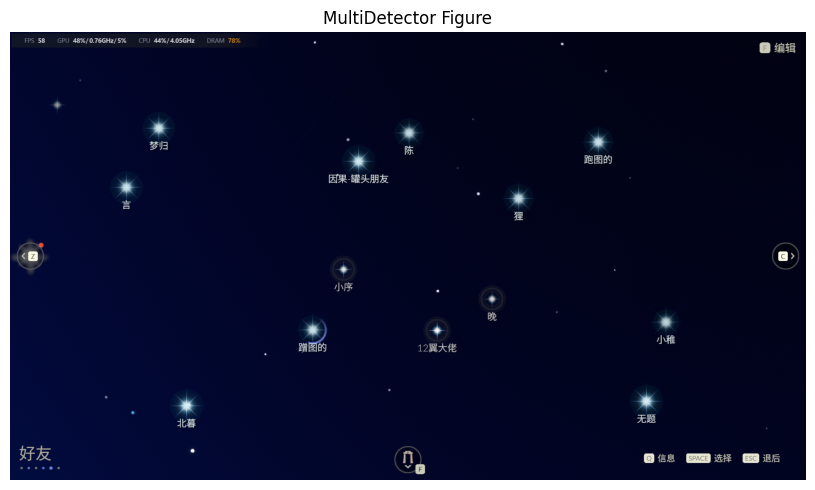



Processing side3.png...
检测为有效的星盘页
图像点为: [[1277.0, 217.0, 9.0, 9.0]]

检测结果: [2] 
[[True, np.float64(-20.0), np.int64(24)]]


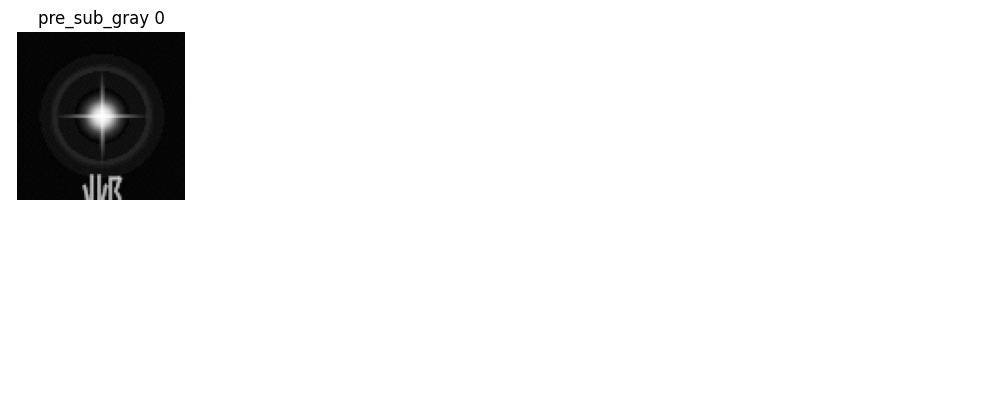

图像点为: [[1403.  843.   16.   17.]
 [ 595.  680.   17.   17.]
 [ 666.  534.   17.   18.]
 [ 698.  273.   18.   19.]]

检测结果: [2, 2, 2, 2] 
[[False, -1, -1], [False, -1, -1], [False, -1, -1], [False, -1, -1]]


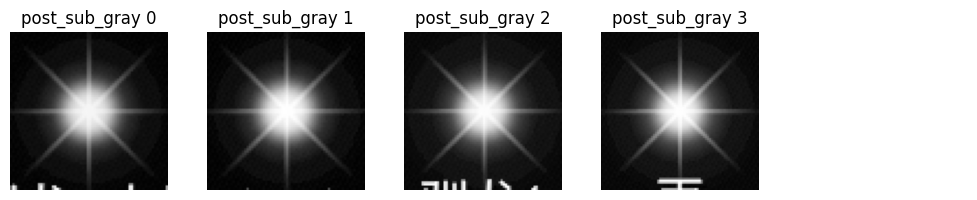

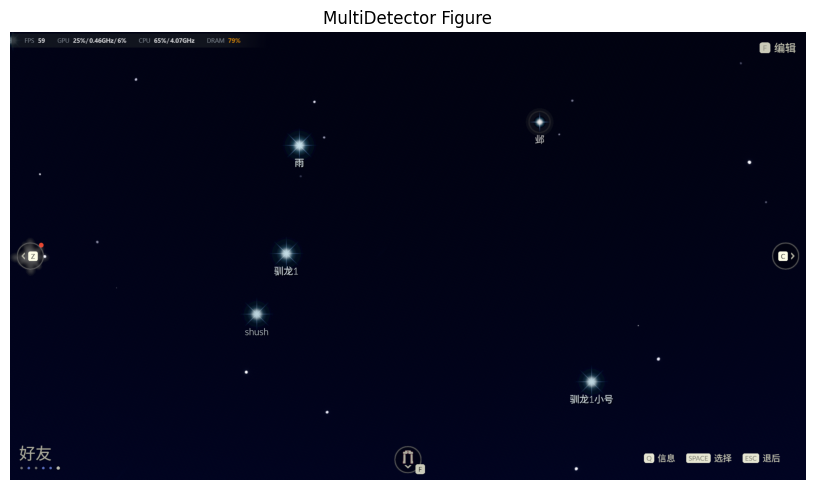

In [50]:
detector = NanokaDetector()  
for filename in os.listdir(os.path.join("source", "data")):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        print(f"\n\nProcessing {filename}...")

        detector.update_image(cv2.cvtColor(cv2.imread(os.path.join("source", "data", filename)), cv2.COLOR_BGR2RGB))
        json_data, img = detector.multi_detector(gray, plot=True, show=True)
    else:
        print(f"Skipping {filename}, not an image file.")